<a href="https://colab.research.google.com/github/SimplyBecca5220/About-Me/blob/main/Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Datasets /85334965-5736-457a-b8d4-a077e6872f84.csv')

# New section

In [ ]:
# Display the first few rows to confirm it loaded correctly
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [ ]:
# Check missing values per column
print("Missing values per channel/feature:")
print(df.isna().sum())

# Calculate total missing values in the entire dataset
total_missing = df.isna().sum().sum()
print(f"\nTotal missing values across the dataset: {total_missing}")

Missing values per channel/feature:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

Total missing values across the dataset: 26


In [7]:
# Drop rows with missing values and save to a clean DataFrame
df_clean = df.dropna()

print(f"Original dataset rows: {len(df)}")
print(f"Cleaned dataset rows: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Original dataset rows: 4572
Cleaned dataset rows: 4546
Rows removed: 26


Correlation Matrix:
                    TV     Radio  Social_Media     Sales
TV            1.000000  0.869158      0.527687  0.999497
Radio         0.869158  1.000000      0.606338  0.868638
Social_Media  0.527687  0.606338      1.000000  0.527446
Sales         0.999497  0.868638      0.527446  1.000000


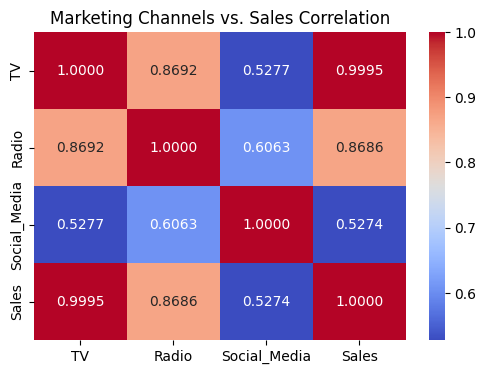

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df_clean[['TV', 'Radio', 'Social_Media', 'Sales']].corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".4f")
plt.title("Marketing Channels vs. Sales Correlation")
plt.show()

In [11]:
from sklearn.linear_model import LinearRegression

# Define independent variables (X) and dependent variable (y)
X = df_clean[['TV', 'Radio', 'Social_Media']]
y = df_clean['Sales']

# Initialize and fit the Multiple Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Print out the calculated regression coefficients (beta weights)
print("Regression Coefficients (Beta values):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.3f}")

print(f"Intercept: {model.intercept_:.3f}")

Regression Coefficients (Beta values):
TV: 3.563
Radio: -0.004
Social_Media: 0.005
Intercept: -0.134


In [12]:
from sklearn.metrics import r2_score

# Make predictions using our trained model
y_pred = model.predict(X)

# Calculate the R-squared score
r2 = r2_score(y, y_pred)
print(f"Model R-squared ($R^2$) Score: {r2:.4f}")

Model R-squared ($R^2$) Score: 0.9990
